# Initialization

PorePy offers different approaches for initializing a simulation:
- explicit initial conditions - the user specifies the initial values for all primary variables.
- implicit initial conditions - the user specifies boundary conditions and source terms at initial time and the solver computes the initial steady state based on these conditions and complying with the governing equations.

In this tutorial, we demonstrate these options using a two-dimensional poroelastic fractured medium. The baseline poromechanics model is extended with appropriate geometry and boundary conditions representing typical lithostatic stress and hydrostatic pressure under gravity. Relevant material parameters as well as hydrostatic pressure and lithostatic stress boundary conditions corresponding to a square domain extending from $y = 1.0$ km to $y = 1.1$ km below the surface are applied to emulate more realistic subsurface conditions.
The code used for this setup is available in the `examples.initialize_poromechanics` module.

## Setting up a simulation with explicit initial conditions

PorePy models provide direct access to the initialization of all primary variables. For example, pressure can be initialized through `ic_values_pressure`, as defined below in `InitialConditionHydrostaticPressureValues`. If not explicitly specified, default values are used; in this example, zero displacement is assigned as the initial condition.

We construct the model described above and visualize the resulting initial state.

In [ ]:
# Model definition.
import porepy as pp
import numpy as np
from porepy.examples.initialize_poromechanics import (
    ModelWithInitialization,
    set_model_parameters,
    set_solver_parameters,
)

We define a model and just call the internal method `prepare_simulation`, which sets the explicits initial conditions as the solution at initial time. We visualize the hydrostatic pressure and displacement. Since the latter is displayed as glyphs, the zero displacement is not visible in the plot.

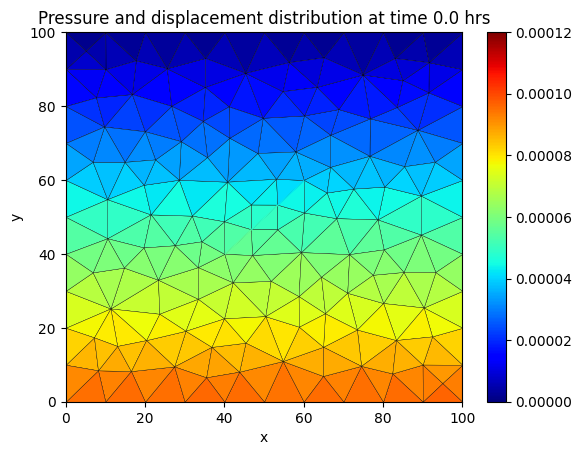

In [ ]:
model_params = set_model_parameters()

# --- Create model instance and plot initial conditions ---
model_with_explicit_initialization = ModelWithInitialization(model_params)
model_with_explicit_initialization.prepare_simulation()
model_with_explicit_initialization.plot_model()

### Complying boundary and initial conditions
For transient simulations, the initial state should be chosen consistently with boundary conditions and source terms. If these are inconsistent, the model will first produce a startup adjustment transient before representing the intended physics. This is not inherently incorrect, but it changes how early-time results should be interpreted. In many subsurface applications, a physically meaningful starting point is a steady or quasi-steady state that is consistent with the imposed data. 

While the initialization performed above is straightforward, it does not comply with the governing equations and boundary conditions. 
If you want to illustrate this, you can run the simulation for a few time steps and observe the initial adjustment transient in the below block.

/workdir/porepy/src/porepy/models/solution_strategy.py:845: UserWarning: PyPardiso could not be imported,
                    falling back on scipy.sparse.linalg.spsolve
  warn(


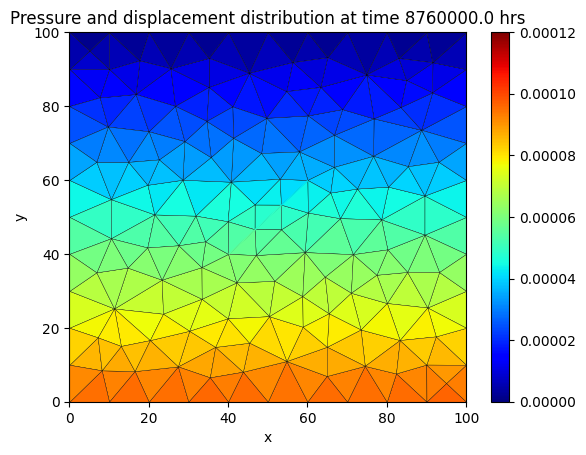

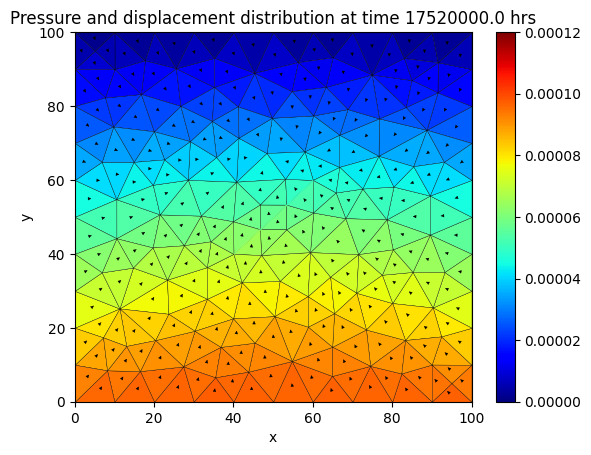

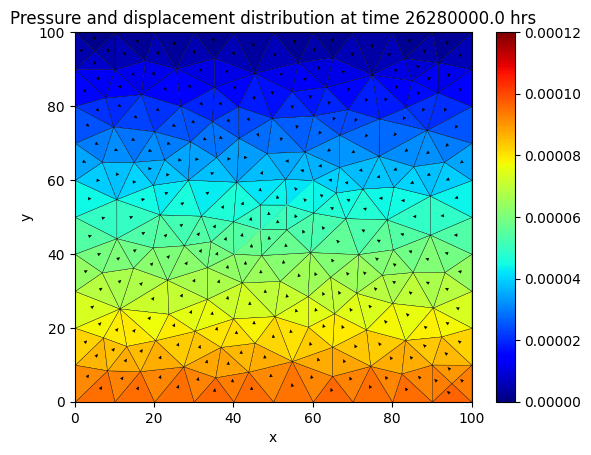

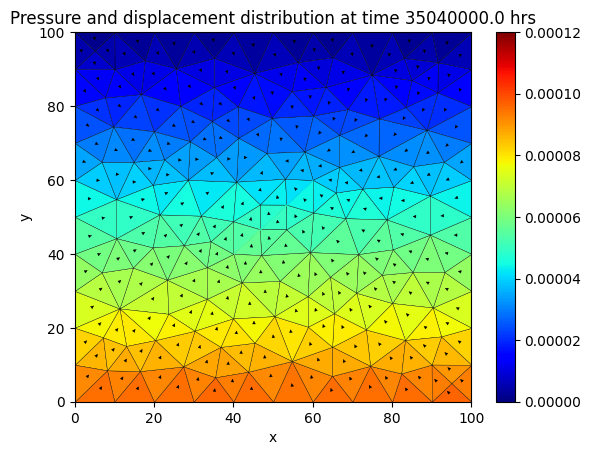

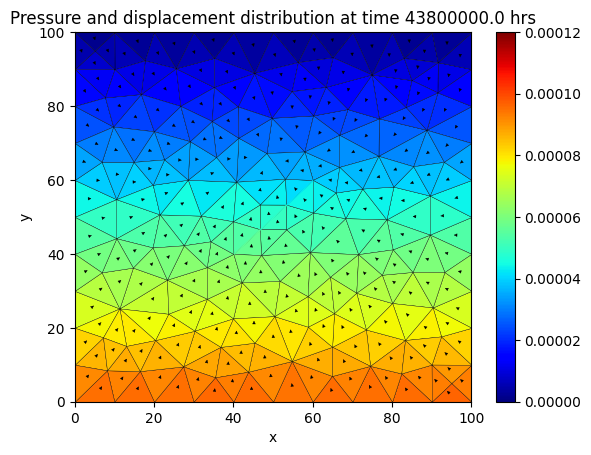

In [ ]:
if illustrate_incompatibility := False:
    model_with_explicit_initialization.plot_incompatible_initial_conditions()
    solver_params_explicit = set_solver_parameters(model_with_explicit_initialization)
    solver_params_explicit["prepare_simulation"] = False

    # --- Run simulation and plot results ---
    pp.ModelRunner(model_with_explicit_initialization, solver_params_explicit).run()

## Implicit steady-state initial conditions
Initializing a simulation for relevant conditions, typically means finding equilibrium conditions. This requires finding complying conditions to governing equations and boundary conditions by solving the problem until steady state just as above. 

PorePy offers the possibility to run such a simulation as initialization, yet without interfering with the time manager and thus allowing for seemless transition to an actual dynamic simulation. To demonstrate this below, we redefine the model to apply all initial boundary conditions also at initial time, and to include dyanmics, here controlled by a time-dependent source term and not active yet at initial time (and thus later not influencing the steady-state).

In [12]:
class InstantantBoundaryConditionsMechanicsNeumann2D(BoundaryConditionsMechanicsNeumann2D):
    """Same as BoundaryConditionsMechanicsNeumann2D, but with instant activation of
    stress boundary conditions."""

    def bc_values_stress(self, boundary_grid: pp.BoundaryGrid) -> np.ndarray:
        """Stress values.

        Parameters:
            boundary_grid: Boundary grid for which boundary values are to be returned.

        Returns:
            Array of boundary values, with one value for each dimension of the
                problem, for each face in the subdomain.

        """
        return self.active_bc_values_stress(boundary_grid)

class ModifiedSource(pp.fluid_mass_balance.FluidMassBalanceEquations):
    """Simple fluid source in the fracture for time > 0."""

    def fluid_source(self, subdomains: list[pp.Grid]) -> pp.ad.Operator:
        """Assign unitary fracture source"""
        # Retrieve internal sources (jump in mortar fluxes) from the base class
        internal_sources: pp.ad.Operator = super().fluid_source(subdomains)

        # External sources are retrieved from SOLUTIONS and wrapped as an AdArray.
        external_sources = pp.ad.TimeDependentDenseArray(
            name="external_sources",
            domains=self.mdg.subdomains(),
        )

        # Add up contributions.
        fluid_source = internal_sources + external_sources
        fluid_source.set_name("Time-dependent fluid source")

        return fluid_source

    def fluid_source_array(self, sd: pp.Grid, time: float) -> list[np.ndarray]:
        """Assign unitary fracture source, only after initialization."""
        if time > pp.SECOND and sd.dim == 1:
            return self.units.convert_units(1e-2 * np.ones(sd.num_cells), "kg * s^-1")
        else:
            return np.zeros(sd.num_cells)


    def update_time_dependent_ad_arrays(self) -> None:
        """Update values of external sources and boundary conditions."""
        super().update_time_dependent_ad_arrays()

        for sd, data in self.mdg.subdomains(return_data=True):
            pp.set_solution_values(
                name="external_sources",
                values=self.fluid_source_array(sd, self.time_manager.time),
                data=data,
                time_step_index=0,
            )
            pp.set_solution_values(
                name="external_sources",
                values=self.fluid_source_array(sd, self.time_manager.time),
                data=data,
                iterate_index=0,
            )

# --- Dynamic model ---

class DynamicModel(
    InstantantBoundaryConditionsMechanicsNeumann2D,
    ModifiedSource,
    ModelWithInitialization,
):
    ...



We redefine the time manager aiming at capturing the early dynamics of the fracture stimulation.

In [5]:
# ---- Redefine the time manager to use shorter time steps typically used for dynamics simulation ----
model_params_for_initialization = set_model_parameters()
model_params_for_initialization["time_manager"] = pp.TimeManager(
    schedule=[0, 24 * pp.HOUR],
    dt_init= 1 * pp.HOUR,
    dt_min_max=(pp.MINUTE, 10 * pp.HOUR),
    constant_dt=False,
    iter_max=25,
    print_info=True,
    iter_optimal_range=(7, 10),
)

# --- Create model instance ---
model_with_implicit_initialization = DynamicModel(model_params_for_initialization)

To better demonstrate the transition towards a dynamic setting, we extend the above setting to include a fracture source just as in the [single phase flow tutorial](single_phase_flow.ipynb). 

In [6]:
# --- Solver parameters for initialization ---

from porepy.numerics.nonlinear.convergence_check import (
    ConvergenceCriteria,
    DivergenceCriteria,
)

# Define solver parameters for initialization, including convergence and divergence criteria.
solver_params_for_initialization = {
    # Standard convergence criteria for the nonlinear solver.
    "nl_convergence_criteria": {
        "inc_rel": pp.IncrementBasedRelativeCriterion(
            tol=1e-6, metric=pp.VariableBasedEuclideanMetric(model_with_implicit_initialization)
        ),
        "res_rel": pp.ResidualBasedRelativeCriterion(
            tol=1e-6, metric=pp.EquationBasedEuclideanMetric(model_with_implicit_initialization)
        ),
    },
    # Divergence criteria for the nonlinear solver.
    "nl_divergence_criteria": {
        "max_iter": pp.MaxIterationsCriterion(max_iterations=25),
        "inc_nan": pp.IncrementBasedNanCriterion(),
        "res_nan": pp.ResidualBasedNanCriterion(),
    },
    # Initialization parameters for the model.
    "initialization": {
        # Define initialization mode and convergence/divergence criteria for steady-state initialization.
        "mode": "steady-state",
        # Convergence criteria for characterizing steady-states (same API as for the nonlinear solver).
        "steady_state_convergence_criteria": ConvergenceCriteria({
            "inc_rel": pp.IncrementBasedRelativeCriterion(
                tol=1e-6, metric=pp.VariableBasedEuclideanMetric(model_with_implicit_initialization)
            ),
            "inc_abs": pp.IncrementBasedAbsoluteCriterion(
                tol=1e-6, metric=pp.VariableBasedEuclideanMetric(model_with_implicit_initialization)
            ),
        }),
        # Divergence criteria for characterizing steady-states (same API as for the nonlinear solver).
        "steady_state_divergence_criteria": DivergenceCriteria({
            "max_iter": pp.MaxIterationsCriterion(max_iterations=25),
            "inc_nan": pp.IncrementBasedNanCriterion(),
            "inc_abs": pp.IncrementBasedAbsoluteCriterion(
                tol=1e10, metric=pp.VariableBasedEuclideanMetric(model_with_implicit_initialization)
            ),
        }),
        # Define pseudo time stepping parameters for the initialization process.
        # NOTE: Non-constant dt is always used to accelerate convergence to steady-state.
        "pseudo_dt_init": 1000 * pp.YEAR,
        "pseudo_dt_max": 100000 * pp.YEAR,
    }
}


We are now ready to perform the initialization. This step is handled at the `ModelRunner` level. Before starting a simulation using the `run` method - which triggers the time loop - we must first call the `initialize` method. This ensures that the model starts from the same initial conditions as those obtained by running a simulation to steady state, as described above. However, the time manager is still reset to time `t=0`. After initialization, we proceed with the dynamic fracture stimulation starting from the steady state, which uses the previously defined time discretization settings with short time steps.

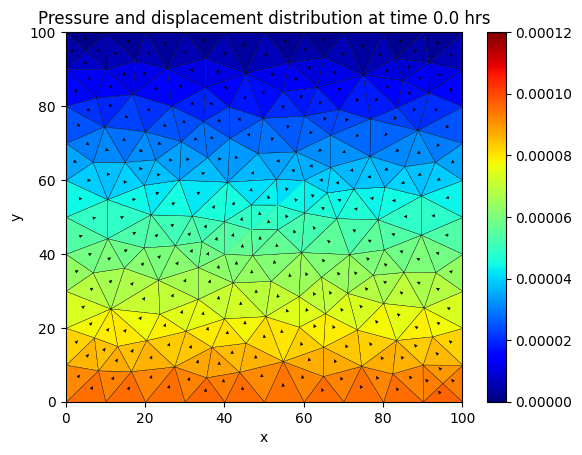

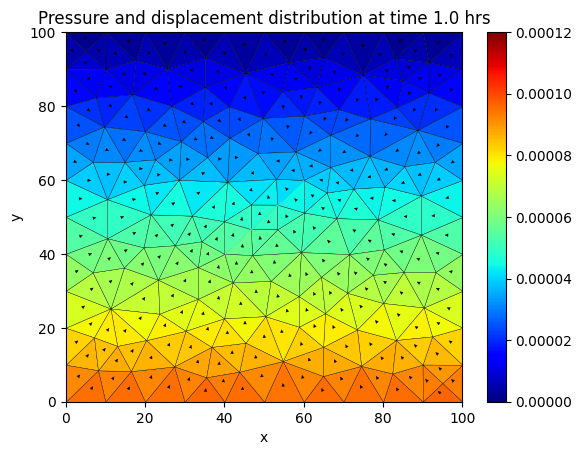

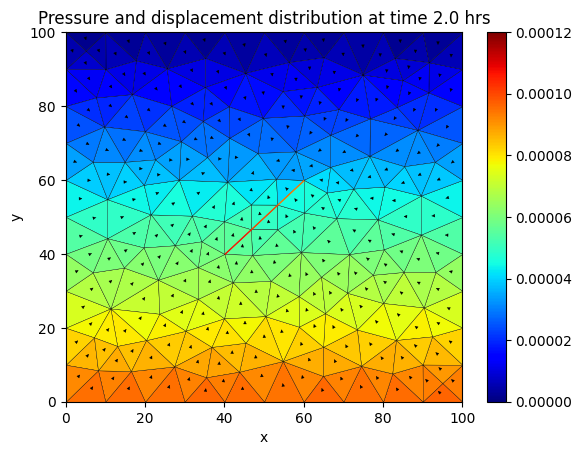

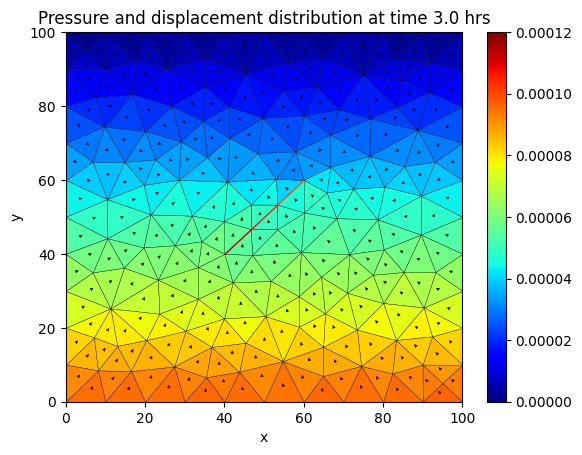

Relaxing time step. Next dt = 4680.0.


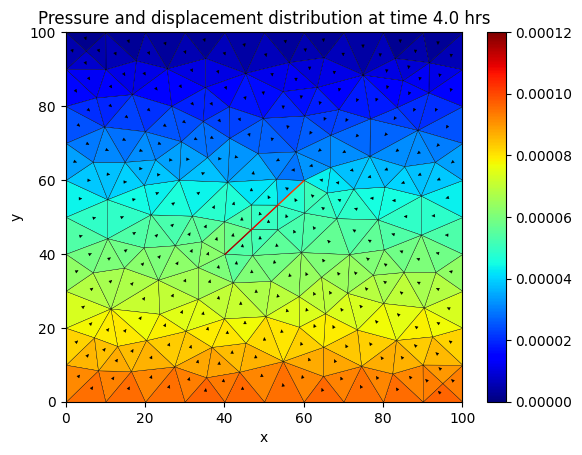

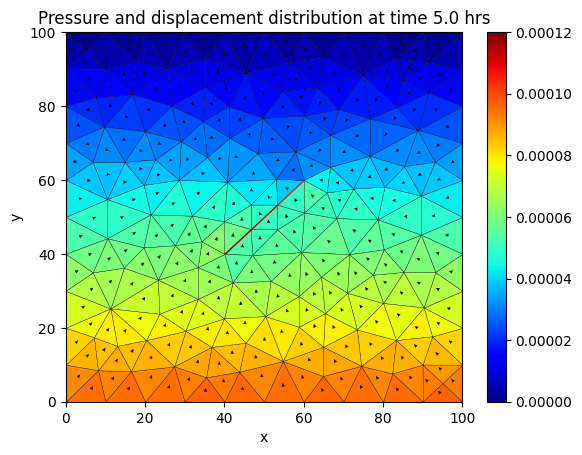

Relaxing time step. Next dt = 6084.0.


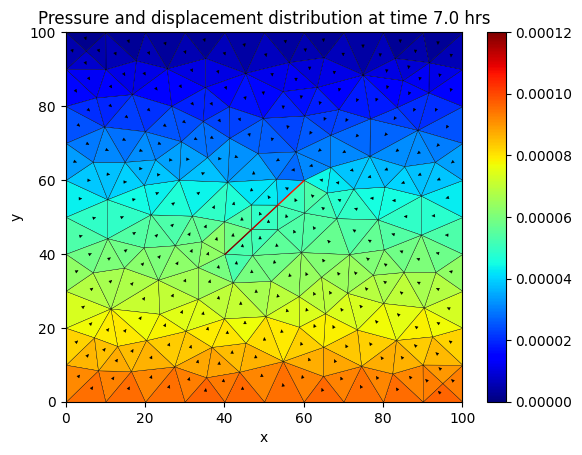

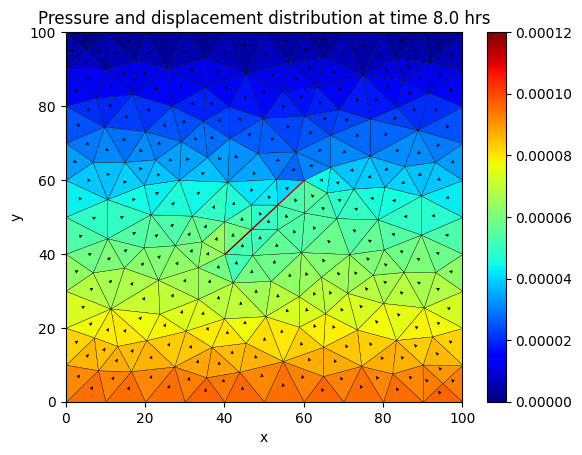

Relaxing time step. Next dt = 7909.2.


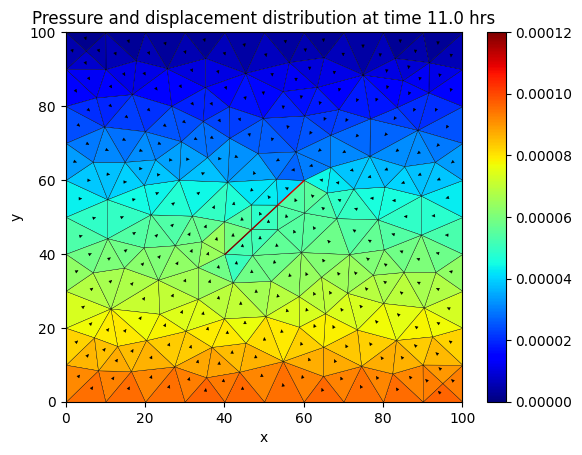

Relaxing time step. Next dt = 10281.960000000001.


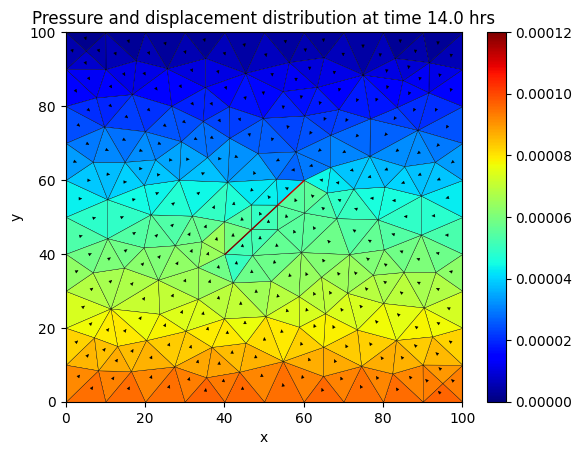

Relaxing time step. Next dt = 13366.548000000003.


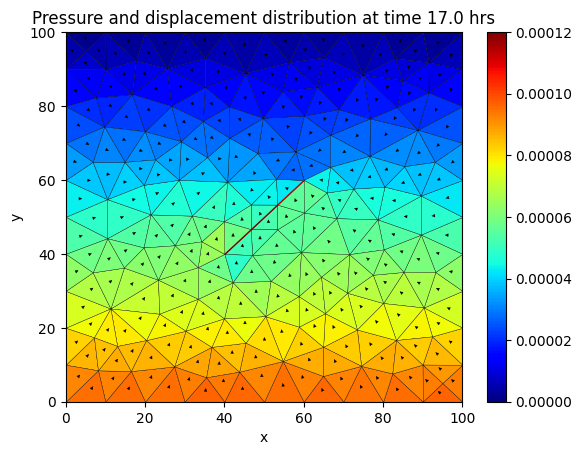

Relaxing time step. Next dt = 17376.512400000003.


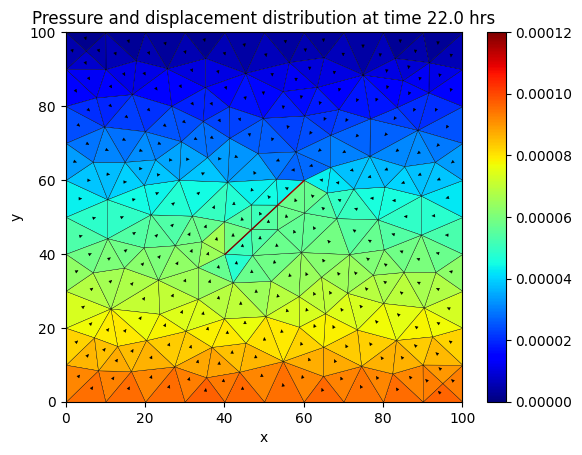

Relaxing time step. Next dt = 22589.466120000005.
Correcting time step to match final time. Final dt = 5137.779599999994.


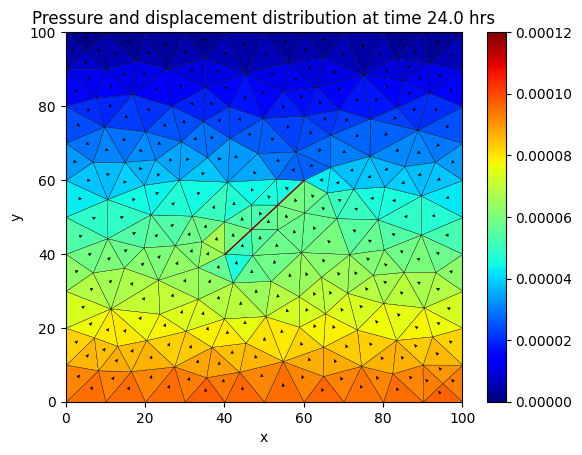

In [7]:
runner = pp.ModelRunner(model_with_implicit_initialization, solver_params_for_initialization)
runner.initialize()
MatplotlibExporting.plot_model(model_with_implicit_initialization)
runner.run()
